# 🧠 Student Performance AI

# Notebook 04 — PyTorch Dataset, DataLoader & Neural Network

## Objective

In this notebook we will:

- Create a custom PyTorch Dataset
- Build DataLoaders
- Define a neural network
- Train the model
- Monitor training loss

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

print(torch.__version__)

2.13.0+cpu


In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
from src.preprocessing import preprocess_data

In [4]:
X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor = preprocess_data(
    "../data/raw/student-performance.csv"
)

In [5]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)

print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([519, 58])
torch.Size([130, 58])
torch.Size([519, 1])
torch.Size([130, 1])


# Creating a Custom PyTorch Dataset

A neural network does not read Pandas DataFrames directly.

PyTorch uses two important classes:

- **Dataset**: Defines how to access a single sample.
- **DataLoader**: Loads data in mini-batches during training.

Using these classes improves performance, keeps the code organized, and is the standard approach for training deep learning models.

In [6]:
from torch.utils.data import Dataset


class StudentDataset(Dataset):
    """
    Custom Dataset for Student Performance Prediction.
    """

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

## Create Training and Testing Datasets

We now convert the training and testing tensors into PyTorch Dataset objects.

The training dataset is used to learn the model parameters.

The testing dataset is kept separate and will only be used later to evaluate how well the trained model performs on unseen data.

In [7]:
train_dataset = StudentDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = StudentDataset(
    X_test_tensor,
    y_test_tensor
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 519
Testing samples: 130


## Creating DataLoaders

A DataLoader divides the dataset into smaller batches.

Instead of sending all training samples through the neural network at once, we process them in mini-batches.

For this project, we use a batch size of 32.

`shuffle=True` is used for the training data so that the model does not always see the training samples in the same order.

For testing, shuffling is unnecessary, so `shuffle=False` is used.

In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 17
Testing batches: 5


## Inspecting a Training Batch

Before training the model, we should verify that the DataLoader is producing data in the expected format.

Each batch should contain:

- 32 samples
- 58 input features
- 32 target values

The final batch can contain fewer than 32 samples because 519 is not exactly divisible by 32.

In [9]:
X_batch, y_batch = next(iter(train_loader))
print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)

Batch X shape: torch.Size([32, 58])
Batch y shape: torch.Size([32, 1])


# Building the Neural Network

Our dataset contains 58 input features.

We will build a simple fully connected neural network:

```
Input Layer
58 features
↓
Linear Layer
64 neurons
↓
ReLU
↓
Linear Layer
32 neurons
↓
ReLU
↓
Output Layer
1 neuron
```

Because this is a regression problem, the final layer does not use a classification activation such as Softmax.

In [10]:
# explIn each line:

class StudentPerformanceModel(nn.Module):
    """
    Neural Network Model for Student Performance Prediction.
    """
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

## Create the Model

In [11]:
input_size = X_train_tensor.shape[1]
model = StudentPerformanceModel(input_size)
print(model)

StudentPerformanceModel(
  (network): Sequential(
    (0): Linear(in_features=58, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [12]:
X_train_tensor.shape[1]

58

Part 7 — Test the Forward Pass

Before training, let's make sure the model can actually process a batch.

In [13]:
predictions = model(X_batch)

print("Input shape     :", X_batch.shape)
print("Prediction shape:", predictions.shape)

Input shape     : torch.Size([32, 58])
Prediction shape: torch.Size([32, 1])


# Loss Function

This project predicts a continuous student performance value, so this is a regression problem.

We will use Mean Squared Error (MSE).

MSE measures the average squared difference between the actual and predicted values.

MSE = 1/n × Σ(y - ŷ)²

A lower MSE means the predictions are closer to the actual values.

In [14]:
criterion = nn.MSELoss()
print("Criterion:", criterion)

Criterion: MSELoss()


# Optimizer

The optimizer updates the neural network parameters based on the gradients calculated during backpropagation.

We will use Adam.

Adam is a popular optimization algorithm because it adapts the learning rate for individual parameters and generally works well for neural network training.

Initial learning rate:

0.001

In [15]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Training the Neural Network

Training follows the following process:

1. Load a batch
2. Perform a forward pass
3. Generate predictions
4. Calculate the loss
5. Clear previous gradients
6. Perform backpropagation
7. Update model parameters

This process is repeated for every batch.

One complete pass through the training dataset is called an epoch.

In [16]:
EPOCHS = 100

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(predictions, y_batch)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{EPOCHS}] "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch [10/100] Loss: 2.0560
Epoch [20/100] Loss: 1.5896
Epoch [30/100] Loss: 1.4595
Epoch [40/100] Loss: 1.0663
Epoch [50/100] Loss: 0.8312
Epoch [60/100] Loss: 0.6438
Epoch [70/100] Loss: 0.5226
Epoch [80/100] Loss: 0.4654
Epoch [90/100] Loss: 0.3514
Epoch [100/100] Loss: 0.2825


# Training Loss Visualization

The training-loss curve helps us understand whether the model is learning.

A generally decreasing curve indicates that the model is reducing its training error over time.

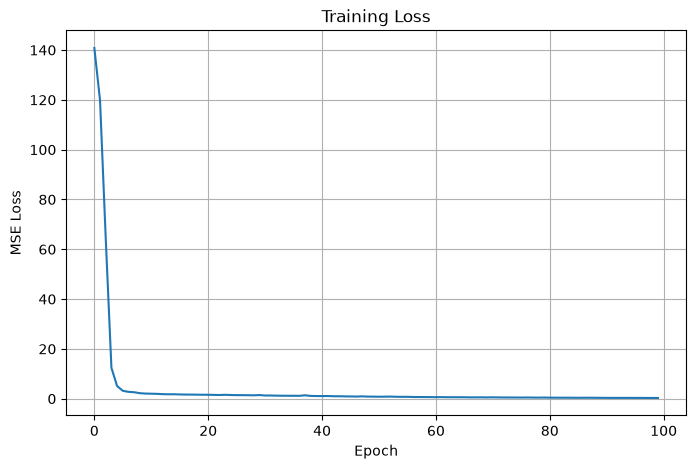

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.grid(True)
plt.show()

In [18]:
print("Initial loss:", train_losses[0])
print("Final loss  :", train_losses[-1])

if train_losses[-1] < train_losses[0]:
    print("Training was successful: loss decreased.")
else:
    print("Warning: loss did not decrease.")

Initial loss: 140.81575595631318
Final loss  : 0.2825208998778287
Training was successful: loss decreased.


## savinfg the model

In [19]:
from pathlib import Path

model_dir = Path("../models/checkpoints")

model_dir.mkdir(
    parents=True,
    exist_ok=True
)

model_path = model_dir / "student_performance_model.pth"

torch.save(
    model.state_dict(),
    model_path
)

print(f"Model saved successfully to: {model_path}")

Model saved successfully to: ..\models\checkpoints\student_performance_model.pth


In [20]:
print("Model exists:", model_path.exists())

Model exists: True


# Professional Checkpoint 

In [21]:
print("=" * 50)
print("MODEL TRAINING CHECKPOINT")
print("=" * 50)

print(f"Training samples : {len(train_dataset)}")
print(f"Testing samples  : {len(test_dataset)}")
print(f"Input features   : {input_size}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Epochs           : {EPOCHS}")
print(f"Initial loss     : {train_losses[0]:.4f}")
print(f"Final loss       : {train_losses[-1]:.4f}")
print(f"Model saved      : {model_path.exists()}")

MODEL TRAINING CHECKPOINT
Training samples : 519
Testing samples  : 130
Input features   : 58
Batch size       : 32
Epochs           : 100
Initial loss     : 140.8158
Final loss       : 0.2825
Model saved      : True
